In [7]:
import pandas as pd
import numpy as np

In [8]:
dane = pd.read_csv("dane/Titanic-Dataset.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'dane/Titanic-Dataset.csv'

In [1]:
import os
print(os.getcwd())

C:\Users\maksr\dane


In [2]:
print(os.listdir("dane"))

FileNotFoundError: [WinError 3] System nie może odnaleźć określonej ścieżki: 'dane'

In [3]:
import os
print(os.getcwd())

C:\Users\maksr\dane


In [4]:
print(os.listdir())

['.ipynb_checkpoints', 'analiza_lotto1.ipynb', 'dzien3_srodowisko_20.08.2026.ipynb', 'dzien4_testowy_plik.csv', 'lotto_wyniki_1957_2026.csv', 'periodic_table_test.ipynb', 'periodic_table_with_all_units.csv', 'Titanic-Dataset.csv', 'titanic_dataset_test.ipynb', 'wykres.png']


In [10]:
print(os.listdir("dane"))

FileNotFoundError: [WinError 3] System nie może odnaleźć określonej ścieżki: 'dane'

In [9]:
print(os.path.exists("dane"))
print(os.path.isdir("dane"))

False
False


In [8]:
dane = pd.read_csv("Titanic-Dataset.csv")
dane.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
dane.shape

(891, 12)

In [12]:
dane.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [13]:
dane.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
dane.duplicated().sum()

np.int64(0)

wstepna eksploracja, brak duplikatow, jest sporo pustych miejsc, szczegolnie duzo w kolumnie "cabin". na tej podstawie zamierzam usunac cala kolumne cabin, a puste miejsca w Age oprawic brakiem wartosci?, w embarked to samo,

sprecyzowanie: uzyje mediany do uzupelnienia kolumny age i najczesciej wystepujacej wartosci do kolumny embarked

In [15]:
dane_czyste = dane.copy()
dane_czyste = dane_czyste.drop(columns=["Cabin"])
dane_czyste["Age"] = dane_czyste["Age"].fillna(dane_czyste["Age"].median())
dane_czyste["Embarked"] = dane_czyste["Embarked"].fillna(dane_czyste["Embarked"].mode()[0])
print(dane_czyste.isna().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [16]:
dane_czyste.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Embarked           str
dtype: object

In [17]:
dane_czyste["Ticket"].unique()

<StringArray>
[       'A/5 21171',         'PC 17599', 'STON/O2. 3101282',
           '113803',           '373450',           '330877',
            '17463',           '349909',           '347742',
           '237736',
 ...
           '349212',           '349217',           '349257',
             '7552', 'C.A./SOTON 34068',  'SOTON/OQ 392076',
           '211536',           '112053',           '111369',
           '370376']
Length: 681, dtype: str

In [18]:
#Stan końcowy danych:
dane_czyste.shape

(891, 11)

Dane surowe to "dane", dane  oczyszczone to "dane_czyste". Brakujace wartosci w kolumnie "Age" zostały zastąpione przez medianę wieku pasażerów (dokładnie 177 wierszy w tej kolumnie). Brakujące wartości w kolumnie "Cabin" wystąpiły aż 687 razy, co stanowi 77% danych, z tego powodu kolumna ta została w całości usunięta ze zbioru danych. Dwie brakujące wartości w kolumnie "Embarked" zastąpiłem na wartości najczęściej występujące w tej kolumnie za pomocą .mode()[0]. Stan początkowy danych: (891, 12), stan koncowy danych: (891, 11)

Lekcja 6

In [19]:
dane_czyste.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [20]:
dane_czyste.groupby(["Pclass", "Sex"])["Survived"].mean()

Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

In [21]:
dane_czyste.groupby("Pclass").agg({
    "Age": "mean",
    "Fare": "max",
    "PassengerId": "count"
})
    

,Age,Fare,PassengerId
Pclass,,,
1,36.812130,512.3292,216
2,29.765380,73.5000,184
3,25.932627,69.5500,491


In [22]:
dane_czyste.sort_values("Age")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,C
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,S
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,C
644,645,1,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,C
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,S
...,...,...,...,...,...,...,...,...,...,...,...
116,117,0,3,"Connors, Mr. Patrick",male,70.50,0,0,370369,7.7500,Q
96,97,0,1,"Goldschmidt, Mr. George B",male,71.00,0,0,PC 17754,34.6542,C
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.00,0,0,PC 17609,49.5042,C
851,852,0,3,"Svensson, Mr. Johan",male,74.00,0,0,347060,7.7750,S


In [23]:
dane_czyste.sort_values(["Pclass", "Age"]).head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
305,306,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,S
297,298,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,S
445,446,1,1,"Dodge, Master. Washington",male,4.00,0,2,33638,81.8583,S
802,803,1,1,"Carter, Master. William Thornton II",male,11.00,1,2,113760,120.0000,S
435,436,1,1,"Carter, Miss. Lucile Polk",female,14.00,1,2,113760,120.0000,S
689,690,1,1,"Madill, Miss. Georgette Alexandra",female,15.00,0,1,24160,211.3375,S
329,330,1,1,"Hippach, Miss. Jean Gertrude",female,16.00,0,1,111361,57.9792,C
504,505,1,1,"Maioni, Miss. Roberta",female,16.00,0,0,110152,86.5000,S
853,854,1,1,"Lines, Miss. Mary Conover",female,16.00,0,1,PC 17592,39.4000,S
307,308,1,1,"Penasco y Castellana, Mrs. Victor de Satode (M...",female,17.00,1,0,PC 17758,108.9000,C


In [24]:
dane_czyste["Pełnoletni"] = dane_czyste["Age"] >= 18
dane_czyste["Pełnoletni"].value_counts()

Pełnoletni
True     778
False    113
Name: count, dtype: int64

In [25]:
dane_czyste["Kategoria_wieku"] = dane_czyste["Age"].apply(
    lambda wiek: "dziecko" if wiek < 18 else ("dorosły" if wiek <= 65 else "senior")
)
print(dane_czyste["Kategoria_wieku"].value_counts())

Kategoria_wieku
dorosły    770
dziecko    113
senior       8
Name: count, dtype: int64


In [26]:
tabela1 = pd.DataFrame({
    "ID": [1, 2, 3, 4, 5],
    "imie": ["Ala", "Bartek", "Celina", "Dawid", "Ewa"]
})

tabela2 = pd.DataFrame({
    "ID_klienta": [3, 2, 1, 3, 2],
    "produkt": ["Laptop", "Ładowarka", "Pralka", "Telefon", "Lampa"],
    "cena": [3500, 90, 1800, 4000, 600]
})
tabela3 = pd.merge(tabela1, tabela2, left_on="ID", right_on="ID_klienta")
print(tabela3)

   ID    imie  ID_klienta    produkt  cena
0   2  Bartek           2  Ładowarka    90
1   3  Celina           3    Telefon  4000
2   3  Celina           3     Laptop  3500
3   2  Bartek           2      Lampa   600
4   1     Ala           1     Pralka  1800


In [27]:
pd.concat([tabela1, tabela2])

,ID,imie,ID_klienta,produkt,cena
0,1.0,Ala,NaN,NaN,NaN
1,2.0,Bartek,NaN,NaN,NaN
2,3.0,Celina,NaN,NaN,NaN
3,4.0,Dawid,NaN,NaN,NaN
4,5.0,Ewa,NaN,NaN,NaN
0,NaN,NaN,3.0,Laptop,3500.0
1,NaN,NaN,2.0,Ładowarka,90.0
2,NaN,NaN,1.0,Pralka,1800.0
3,NaN,NaN,3.0,Telefon,4000.0
4,NaN,NaN,2.0,Lampa,600.0


In [28]:
x = dane_czyste.groupby("Embarked").agg({
    "Fare": "mean"
})
print(x.sort_values("Fare", ascending=False))

               Fare
Embarked           
C         59.954144
S         27.243651
Q         13.276030


W tej lekcji najbardziej zaintrygowala mnie srednia przezywalnosc kobiet w stosunku do przezywalnosci mezczyzn, a takze dosc mala liczba pasazerow klasy 2 oraz fakt ze srednio najstarsi pasazerowie byli w 1 klasie. 

Lekcja 7 - początek

In [29]:
import matplotlib.pyplot as plt

(array([ 24.,  16.,   7.,   7.,  10.,   5.,   8.,  23.,  39.,  40.,  52.,
         46.,  42., 220.,  47.,  37.,  32.,  41.,  18.,  27.,  21.,  14.,
         17.,  18.,  16.,  13.,   9.,   7.,   7.,   6.,   7.,   4.,   4.,
          0.,   2.,   3.,   1.,   0.,   0.,   1.]),
 array([ 0.42  ,  2.4095,  4.399 ,  6.3885,  8.378 , 10.3675, 12.357 ,
        14.3465, 16.336 , 18.3255, 20.315 , 22.3045, 24.294 , 26.2835,
        28.273 , 30.2625, 32.252 , 34.2415, 36.231 , 38.2205, 40.21  ,
        42.1995, 44.189 , 46.1785, 48.168 , 50.1575, 52.147 , 54.1365,
        56.126 , 58.1155, 60.105 , 62.0945, 64.084 , 66.0735, 68.063 ,
        70.0525, 72.042 , 74.0315, 76.021 , 78.0105, 80.    ]),
 <BarContainer object of 40 artists>)

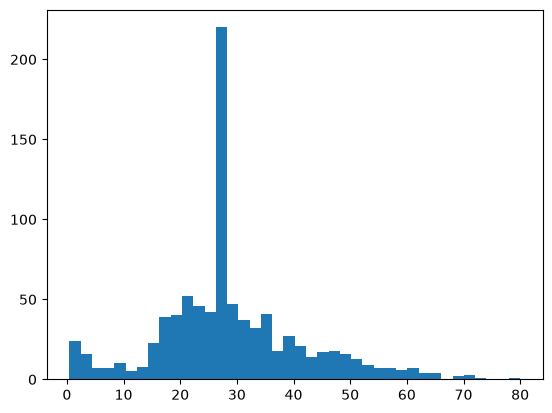

In [30]:
plt.hist(dane_czyste["Age"], bins=40)

<Axes: xlabel='Pclass'>

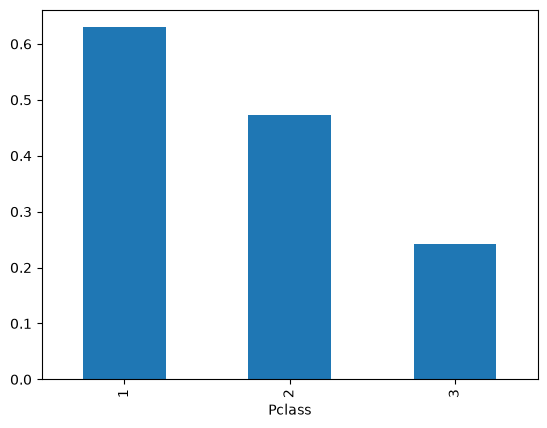

In [31]:
dane_czyste.groupby("Pclass")["Survived"].mean().plot(kind="bar")

Text(0, 0.5, 'cena biletu')

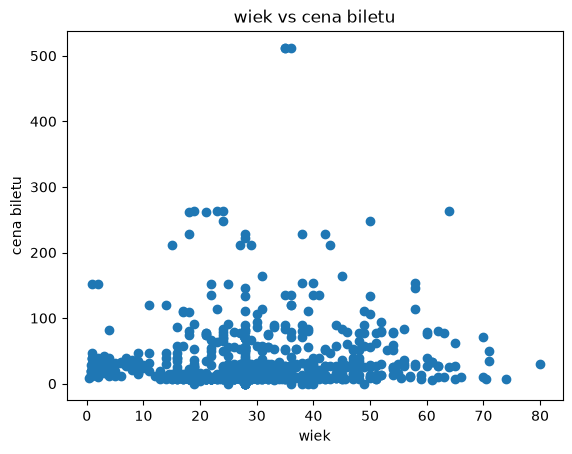

In [32]:
plt.scatter(dane_czyste["Age"], dane_czyste["Fare"])
plt.title("wiek vs cena biletu")
plt.xlabel("wiek")
plt.ylabel("cena biletu")

In [33]:
import seaborn as sns

<Axes: xlabel='Pclass', ylabel='Age'>

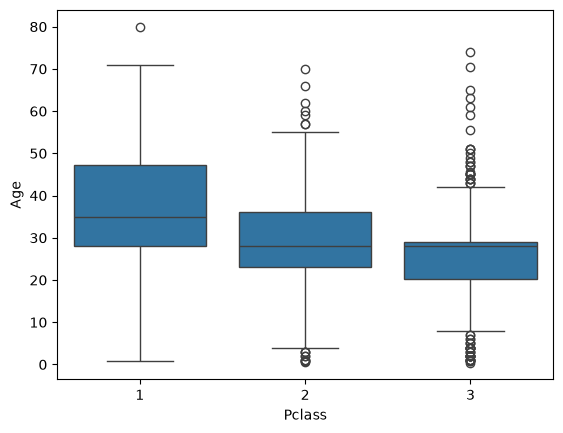

In [34]:
#rozkład pudełkowy, boxplot
sns.boxplot(x = dane_czyste["Pclass"], y = dane_czyste["Age"], data = dane_czyste)

<Axes: xlabel='Pclass', ylabel='count'>

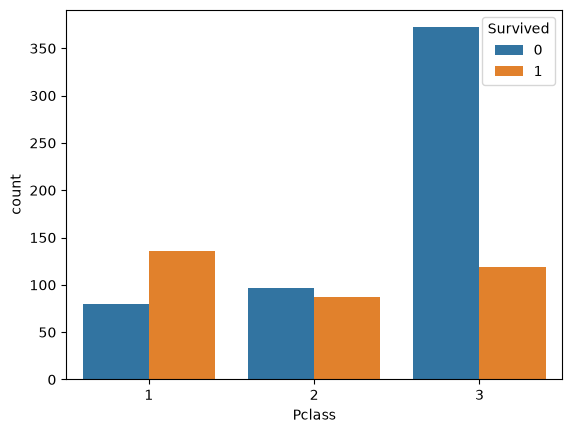

In [35]:
sns.countplot(x="Pclass", hue="Survived", data = dane_czyste)

<Axes: >

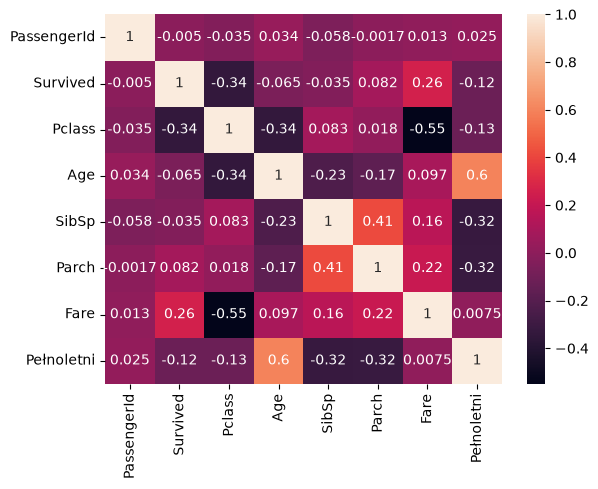

In [36]:
korelacje = dane_czyste.corr(numeric_only=True)
sns.heatmap(korelacje, annot=True)

Text(0.5, 1.0, 'Cena biletów w każdej klasie')

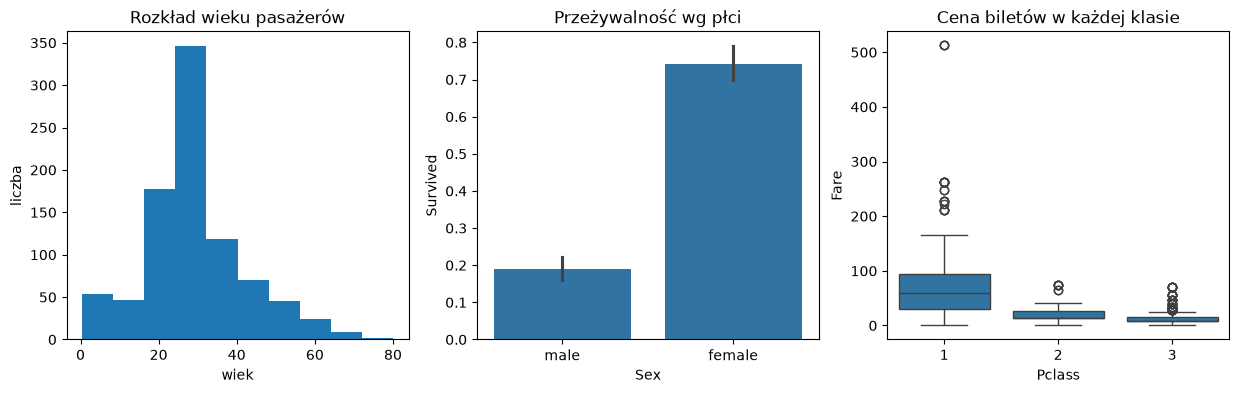

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(dane_czyste["Age"])
axes[0].set_title("Rozkład wieku pasażerów")
axes[0].set_xlabel("wiek")
axes[0].set_ylabel("liczba")
sns.barplot(x = "Sex", y = "Survived", data = dane_czyste, ax=axes[1])
axes[1].set_title("Przeżywalność wg płci")
sns.boxplot(x = "Pclass", y = "Fare", data = dane_czyste, ax=axes[2])
axes[2].set_title("Cena biletów w każdej klasie")

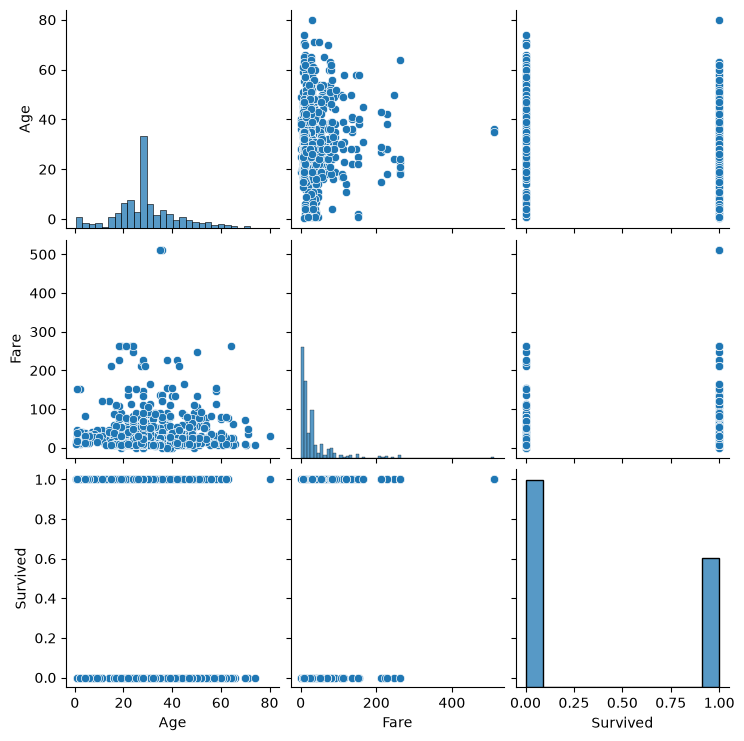

In [38]:
sns.pairplot(dane_czyste[["Age", "Fare", "Survived"]])

(array([ 24.,  16.,   7.,   7.,  10.,   5.,   8.,  23.,  39.,  40.,  52.,
         46.,  42., 220.,  47.,  37.,  32.,  41.,  18.,  27.,  21.,  14.,
         17.,  18.,  16.,  13.,   9.,   7.,   7.,   6.,   7.,   4.,   4.,
          0.,   2.,   3.,   1.,   0.,   0.,   1.]),
 array([ 0.42  ,  2.4095,  4.399 ,  6.3885,  8.378 , 10.3675, 12.357 ,
        14.3465, 16.336 , 18.3255, 20.315 , 22.3045, 24.294 , 26.2835,
        28.273 , 30.2625, 32.252 , 34.2415, 36.231 , 38.2205, 40.21  ,
        42.1995, 44.189 , 46.1785, 48.168 , 50.1575, 52.147 , 54.1365,
        56.126 , 58.1155, 60.105 , 62.0945, 64.084 , 66.0735, 68.063 ,
        70.0525, 72.042 , 74.0315, 76.021 , 78.0105, 80.    ]),
 <BarContainer object of 40 artists>)

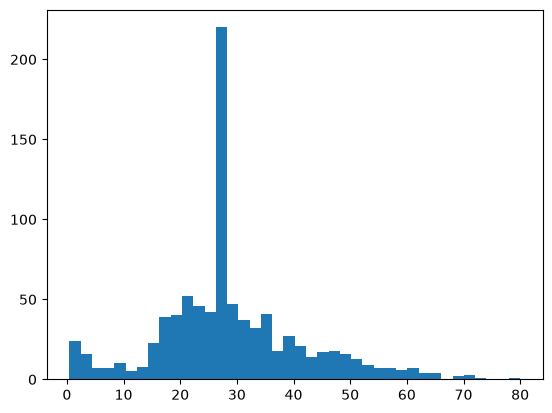

In [39]:
plt.hist(dane_czyste["Age"], bins=40)

<Axes: xlabel='Age', ylabel='Count'>

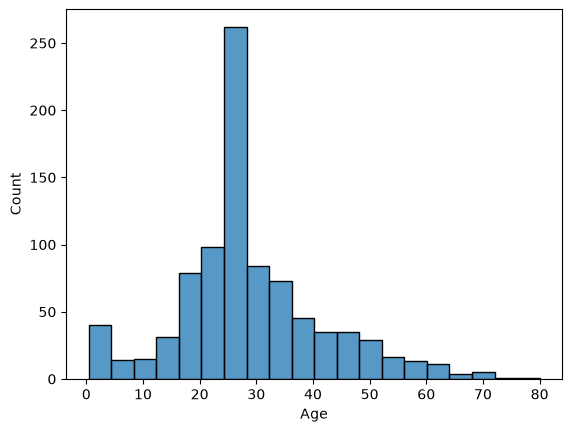

In [40]:
sns.histplot(dane_czyste["Age"], bins=20)

wersja histogramu z sns.histplot jest bardziej czytelna niz wersja z plt.hist. Słupki sa lepiej oddzielone i dodatkowo osie sa automatycznie podpisane

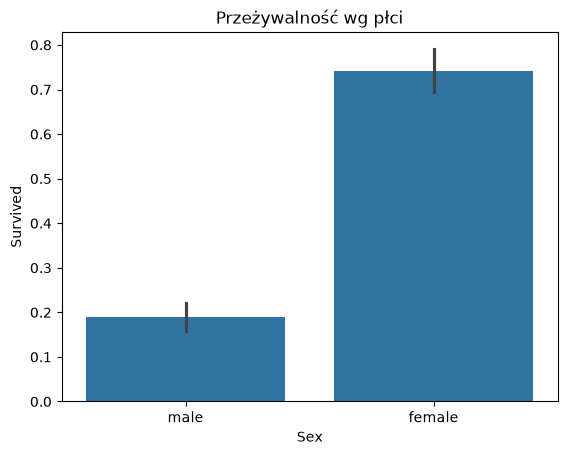

In [41]:
sns.barplot(x = "Sex", y = "Survived", data = dane_czyste)
plt.title("Przeżywalność wg płci")
plt.savefig("wykres.png")

#Lekcja 8

In [42]:
from scipy import stats

<Axes: ylabel='Count'>

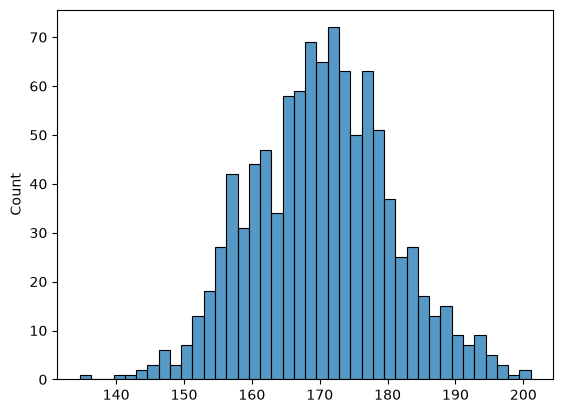

In [43]:
probka = stats.norm.rvs(loc=170, scale=10, size=1000)
sns.histplot(probka, bins=40)

In [44]:
stats.norm.cdf(180, loc=170, scale=10)

np.float64(0.8413447460685429)

wynik powyżej oznacza ze biorąc jedną osobę z zadanej populacji (średni wzrost = 170 i odchylenie standardowe = 10 cm), to jest 84,13% szans ze ta osoba bedzie miala wzrost ponizej 180

In [45]:
stats.binom.pmf(k=3, n=10, p=0.5)

np.float64(0.1171875)

In [46]:
proba = np.random.binomial(n=10, p=0.5, size=100_000)
print(proba[:10])

[6 4 5 4 6 5 7 5 4 4]


In [47]:
mezczyzni = dane_czyste[dane_czyste["Sex"] == "male"]["Age"].dropna()
kobiety = dane_czyste[dane_czyste["Sex"] == "female"]["Age"].dropna()
statystyka, p_wartosc = stats.ttest_ind(mezczyzni, kobiety)
print(f"wartość p: {p_wartosc}")
print(f"statystyka: {statystyka}")

wartość p: 0.015381536989875318
statystyka: 2.4279606481426024


In [48]:
ocalali = dane_czyste[dane_czyste["Survived"] == 1]["Age"].dropna()
zabici = dane_czyste[dane_czyste["Survived"] == 0]["Age"].dropna()
statystyka, p_wartosc = stats.ttest_ind(ocalali, zabici)
print(f"wartość p: {p_wartosc}")

wartość p: 0.05276068847585549


In [49]:
tabela = pd.crosstab(dane_czyste["Sex"], dane_czyste["Survived"])
chi2, p_wartosc, dof, oczekiwana = stats.chi2_contingency(tabela)
print(p_wartosc)
print(chi2)

1.1973570627755645e-58
260.71702016732104


In [50]:
tabela2 = pd.crosstab(dane_czyste["Pclass"], dane_czyste["Survived"])
chi2, p_wartosc, dof, oczekiwana = stats.chi2_contingency(tabela2)
print(p_wartosc)

4.549251711298793e-23


In [51]:
wiek = dane_czyste["Age"].dropna()
srednia = wiek.mean()
blad_standardowy = stats.sem(wiek)
przedzial = stats.t.interval(
    confidence=0.95,
    df=len(wiek)-1,
    loc=srednia,
    scale=blad_standardowy
)
print(f"średni wiek:{srednia: .2f}")
print(f"błąd standardowy: {blad_standardowy: .2f}")
print(f"95% przedział ufności: ({przedzial[0]: .2f}, {przedzial[1]: .2f})")

średni wiek: 29.36
błąd standardowy:  0.44
95% przedział ufności: ( 28.51,  30.22)


na 95 % pewności prawdziwa średnia wieku pasażerów (nie tylko dla tej konkretnej próbki danych) mieści się w przedziale od 28.51 do 30.22 lat. 

hipoteza zerowa(H0): płeć pasażera i przeżywalność są od siebie znacząco zależne
chi2 = 260, p_wartosc = 1,2 * 10^-58
interpretacja: p_wartosc jest drastycznie ponizej progu 0,05, jednoczesnie chi2 jest bardzo wysokie. Potwierdzenie H0
Wniosek: plec pasazera miala duzy wplyw na przezywalnosc na titanicu - koniec lekcji 8

fragment lekcnji 9

In [52]:
from scipy import stats
from scipy.spatial import distance

In [53]:
kolumny = ["Age", "Fare", "SibSp", "Parch"]
X = dane_czyste[kolumny].to_numpy()

In [54]:
print(type(X))
print(X.shape)
print(X[:5])

<class 'numpy.ndarray'>
(891, 4)
[[22.      7.25    1.      0.    ]
 [38.     71.2833  1.      0.    ]
 [26.      7.925   0.      0.    ]
 [35.     53.1     1.      0.    ]
 [35.      8.05    0.      0.    ]]


In [55]:
kolumny = ["Age", "Fare", "SibSp", "Parch"]
for i, nazwa in enumerate(kolumny):
    print(f"{nazwa}: min={X[:, i].min():.2f}, max={X[:, i].max():.2f}")

Age: min=0.42, max=80.00
Fare: min=0.00, max=512.33
SibSp: min=0.00, max=8.00
Parch: min=0.00, max=6.00


In [56]:
X_standaryzowane = (X - X.mean(axis=0)) / X.std(axis=0)
kolumny = ["Age", "Fare", "SibSp", "Parch"]
for i, nazwa in enumerate(kolumny):
    print(f"{nazwa}: min={X_standaryzowane[:, i].min():.2f}, max={X_standaryzowane[:, i].max():.2f}")

Age: min=-2.22, max=3.89
Fare: min=-0.65, max=9.67
SibSp: min=-0.47, max=6.78
Parch: min=-0.47, max=6.97


In [57]:
print(X_standaryzowane.mean(axis=0))
print(X_standaryzowane.std(axis=0))

[2.27277979e-16 3.98733297e-18 4.38606627e-17 5.38289951e-17]
[1. 1. 1. 1.]


In [58]:
#odleglosc miedzy dwoma pasazderami przed standaryzacja:
pasazer_1 = X[0]
pasazer_5 = X[4]
odleglosc_surowa = np.sqrt(np.sum((pasazer_1 - pasazer_5) ** 2))
print(f"Odleglosc na surowych danych: {odleglosc_surowa:.3f}")

Odleglosc na surowych danych: 13.063


In [59]:
#odleglosc miedzy dwoma pasazderami po standaryzacji:
pasazer_1 = X_standaryzowane[0]
pasazer_5 = X_standaryzowane[4]
odleglosc_standaryzowana = np.sqrt(np.sum((pasazer_1 - pasazer_5) ** 2))
print(f"Odleglosc na standaryzowanych danych: {odleglosc_standaryzowana:.3f}")                               

Odleglosc na standaryzowanych danych: 1.350


dla surowych danych odleglosc miedzy wektorem (pasazer_1) i wektorem (pasazer_5) wynosi 13,063. dla danych po standaryzacji jest to 1,350. Odleglosc ta jest w pierwszym przypadku zdominowana prawdopodobnie przez cene biletu ("Fare") ze wzgledu na jej najwiekszy sposrod wszystkich kolumn rozrzut (max - min). Po standaryzacji wplyw tej dominacji znika, co skutkuje ok. 10-krotnym zmniejszeniem obliczanej odleglosci. 

In [60]:
from sklearn.preprocessing import StandardScaler

In [61]:
scaler = StandardScaler()
X_sklearn = scaler.fit_transform(X)
print(X_standaryzowane[:5])
print(X_sklearn[:5])

[[-0.56573646 -0.50244517  0.43279337 -0.47367361]
 [ 0.66386103  0.78684529  0.43279337 -0.47367361]
 [-0.25833709 -0.48885426 -0.4745452  -0.47367361]
 [ 0.4333115   0.42073024  0.43279337 -0.47367361]
 [ 0.4333115  -0.48633742 -0.4745452  -0.47367361]]
[[-0.56573646 -0.50244517  0.43279337 -0.47367361]
 [ 0.66386103  0.78684529  0.43279337 -0.47367361]
 [-0.25833709 -0.48885426 -0.4745452  -0.47367361]
 [ 0.4333115   0.42073024  0.43279337 -0.47367361]
 [ 0.4333115  -0.48633742 -0.4745452  -0.47367361]]


In [62]:
roznica = np.abs(X_standaryzowane - X_sklearn)
print(f"Maksymalna różnica: {roznica.max():.10f}")

Maksymalna różnica: 0.0000000000


In [63]:
from sklearn.decomposition import PCA

In [64]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_standaryzowane)
print(X_pca.shape)
print(X_pca[:5])

(891, 2)
[[ 0.01632106 -0.82147069]
 [-0.00829251  0.94866398]
 [-0.65389609 -0.53856685]
 [-0.04327178  0.52707353]
 [-0.89781645 -0.06403922]]


In [65]:
print(pca.explained_variance_ratio_)

[0.40662092 0.27577972]


explained_variance_radio daŁ wynik 0,407 i 0,276. W duzym skrocie PCA zredukowalo dane w 4 wymiarach (4 kolumny) do danych w dwoch wymiarach (2 kolumny) za pomoca laczenia w jedna ceche kilku silnie ze soba powiazanych wartosci. Wartosci uzyskane po explained_variance oznaczaja ze pierwszy nowy wymiar tlumaczy ok. 40,7% oryginalnej zmiennosci danych, a drugi nowy wymiar tlumaczy 27,6 %.

In [66]:
suma = pca.explained_variance_ratio_.sum()
suma_procent = suma * 100
print(f"Łącznie: {suma_procent:.2f}%")

Łącznie: 68.24%


łącznie te 2 nowe wymiary tlumacza ponad 68 % oryginalnej zmiennosci danych

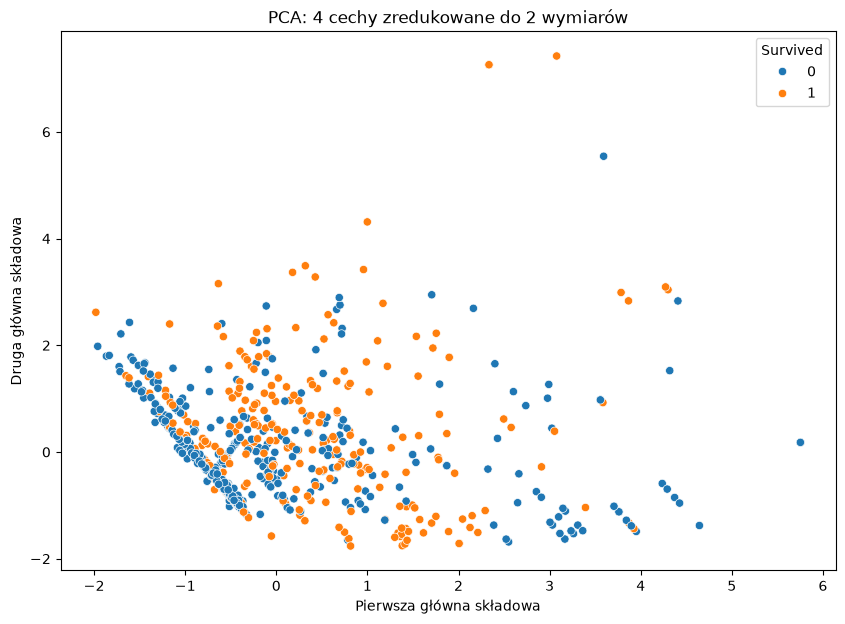

In [68]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dane_czyste["Survived"])
plt.title("PCA: 4 cechy zredukowane do 2 wymiarów")
plt.xlabel("Pierwsza główna składowa")
plt.ylabel("Druga główna składowa")
plt.show()

In [71]:
kowariancja = np.cov(X_standaryzowane.T)
print(kowariancja)
korelacja = dane_czyste[["Age", "Fare", "SibSp", "Parch"]].corr(numeric_only=True)
print(korelacja)

[[ 1.0011236   0.09679706 -0.23355846 -0.17267575]
 [ 0.09679706  1.0011236   0.15983043  0.21646789]
 [-0.23355846  0.15983043  1.0011236   0.41530381]
 [-0.17267575  0.21646789  0.41530381  1.0011236 ]]
            Age      Fare     SibSp     Parch
Age    1.000000  0.096688 -0.233296 -0.172482
Fare   0.096688  1.000000  0.159651  0.216225
SibSp -0.233296  0.159651  1.000000  0.414838
Parch -0.172482  0.216225  0.414838  1.000000


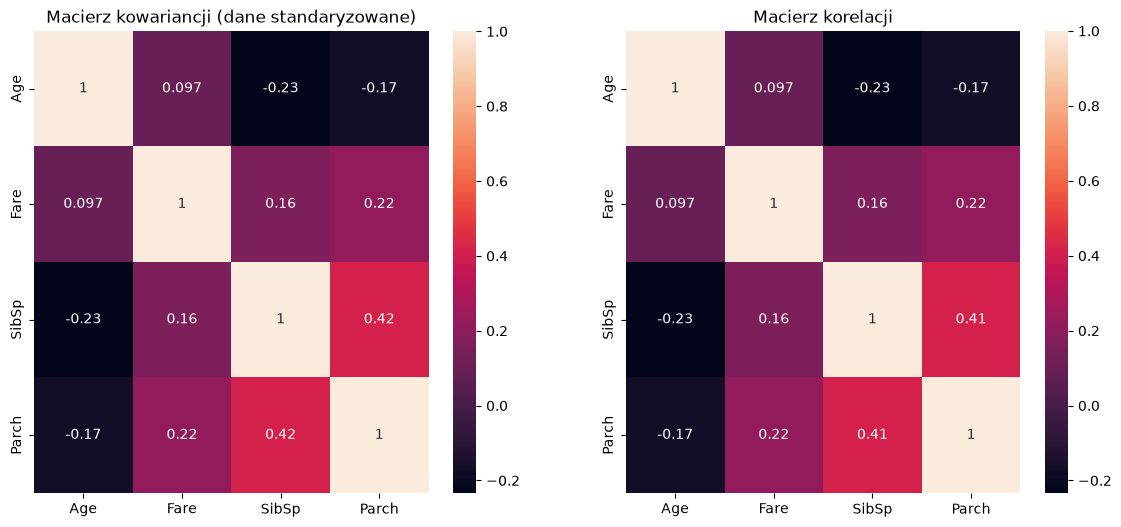

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(kowariancja, annot=True, xticklabels=["Age","Fare","SibSp","Parch"],
            yticklabels=["Age","Fare","SibSp","Parch"], ax=axes[0])
axes[0].set_title("Macierz kowariancji (dane standaryzowane)")

sns.heatmap(korelacja, annot=True, ax=axes[1])
axes[1].set_title("Macierz korelacji")

plt.show()

In [75]:
print(np.allclose(kowariancja, korelacja.values, atol=0.01))

True


## Refleksja: czego brakuje do trenowania modelu

Mając macierz cech X (standaryzowaną), do faktycznego trenowania modelu ML
przewidującego Survived potrzebne są jeszcze:

1. **Etykiety (y)** — rzeczywiste wartości Survived dla każdego pasażera,
   których model będzie się uczył przewidywać na podstawie cech X.

2. **Podział na zbiór treningowy i testowy** — bez tego, ocena modelu na
   danych, na których się uczył, byłaby nieuczciwa (ryzyko przeuczenia,
   czyli "zapamiętania" danych zamiast nauczenia się ogólnych wzorców).
   Standardowo dzieli się dane np. 80% (trening) / 20% (test).

To jest dokładnie to, czym zajmiemy się w scikit-learn — train_test_split()
do podziału danych, oraz fit()/predict() do trenowania i testowania modelu.

## poczatek lekcji 10 ##

In [76]:
kolumny_cech = ["Age", "Pclass"]
dane_do_modelu = dane_czyste[kolumny_cech + ["Fare"]].dropna()

X = dane_do_modelu[kolumny_cech]
y = dane_do_modelu["Fare"]

In [77]:
print(X.shape)
print(y.shape)
print(X.head())
print(y.head())

(891, 2)
(891,)
    Age  Pclass
0  22.0       3
1  38.0       1
2  26.0       3
3  35.0       1
4  35.0       3
0     7.2500
1    71.2833
2     7.9250
3    53.1000
4     8.0500
Name: Fare, dtype: float64


In [78]:
print(dane_czyste["Age"].isna().sum())
print(dane_czyste["Pclass"].isna().sum())
print(dane_czyste["Fare"].isna().sum())

0
0
0


In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(712, 2)
(179, 2)


In [81]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print(model.coef_)          # "wagi" - jak bardzo każda cecha wpływa na wynik tutaj:  # współczynniki dla [Age, Pclass]
print(model.intercept_)       # "wyraz wolny" - wartość bazowa, gdy wszystkie cechy = 0

[ -0.40190866 -36.55219357]
129.4923331395129


przewidywana_cena = intercept_ + (coef_[0] × Age) + (coef_[1] × Pclass)
przewidywana_cena = 129.49 + (-0.40 × Age) + (-36.55 × Pclass)

Model regresji liniowej: Fare = 129.49 - 0.40×Age - 36.55×Pclass

Interpretacja:
- Pclass ma DUŻO silniejszy wpływ na cenę niż Age (36.55 vs 0.40) — spójne
  z wcześniej zaobserwowaną silną korelacją Pclass-Fare (Dzień 6-7).
- Wzrost klasy o 1 (np. z 1 na 2) wiąże się ze spadkiem przewidywanej ceny
  o ~36.55, przy tym samym wieku.
- Wiek ma minimalny wpływ na przewidywaną cenę biletu.

In [83]:
from sklearn.metrics import mean_squared_error, r2_score

predykcje = model.predict(X_test) 
mse = mean_squared_error(y_test, predykcje)   # średni błąd kwadratowy - im MNIEJSZY, tym lepiej
r2 = r2_score(y_test, predykcje)                # pamiętasz r² z Dnia 9! - im BLIŻEJ 1, tym lepiej

print(mse)
print(r2)

1051.47498563
0.3205022235412077


In [84]:
rmse = mse ** 0.5   # pierwiastek z MSE - "cofa" kwadrat, wraca do jednostek oryginalnych (dolary!)
print(f"RMSE: {rmse:.2f}")

RMSE: 32.43


r2 to procent zmienności, którą wytłumaczył model. W tym wypadku r2 = 32%, co oznacza, że model wyjaśnia jedynie 32% zmienności ceny biletu (Fare) — pozostałe 68% zmienności wynika z czynników, których nie uchwycił ten prosty model (Age, Pclass). MSE = 1051 (brak jednostki / dolar^2 - brak sensu fizycznego), RMSE = 32,43 dolary. Wynik jest umiarkowany/niski, co sugeruje, że sama
klasa pasażerska i wiek to niewystarczające predyktory ceny — rzeczywista cena
zależała prawdopodobnie od dodatkowych czynników nieuchwyconych w tym modelu
(konkretna kabina, czas zakupu biletu, itp.).

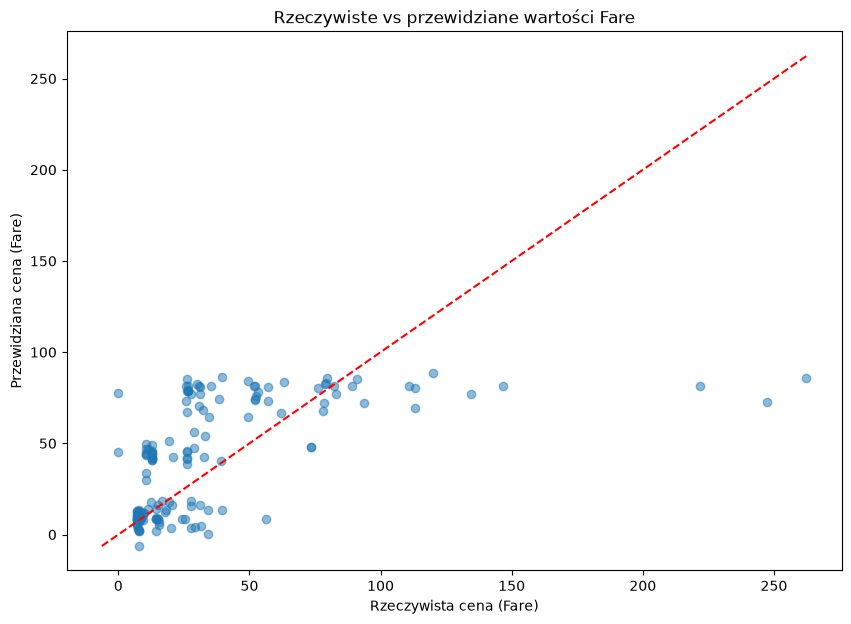

In [85]:
plt.figure(figsize=(10, 7))
# Punkty: rzeczywiste (oś X) vs przewidziane (oś Y)
plt.scatter(y_test, predykcje, alpha=0.5)

# Linia referencyjna y=x (idealne przewidywania leżałyby DOKŁADNIE na tej linii)
min_wartosc = min(y_test.min(), predykcje.min())
max_wartosc = max(y_test.max(), predykcje.max())
plt.plot([min_wartosc, max_wartosc], [min_wartosc, max_wartosc], color="red", linestyle="--")

plt.xlabel("Rzeczywista cena (Fare)")
plt.ylabel("Przewidziana cena (Fare)")
plt.title("Rzeczywiste vs przewidziane wartości Fare")
plt.show()

In [89]:
kolumny_cech2 = ["Age", "Pclass"]
dane_do_modelu2 = dane_czyste[kolumny_cech2 + ["Survived"]].dropna()

X2 = dane_do_modelu2[kolumny_cech2]
y2 = dane_do_modelu2["Survived"]

In [90]:
print(dane_czyste["Age"].isna().sum())
print(dane_czyste["Pclass"].isna().sum())
print(dane_czyste["Survived"].isna().sum())

0
0
0


In [91]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(712, 2)
(179, 2)


In [95]:
from sklearn.linear_model import LogisticRegression
model_klasyfikacja = LogisticRegression()
model_klasyfikacja.fit(X2_train, y2_train)
predykcje2 = model_klasyfikacja.predict(X2_test)
print(model_klasyfikacja.coef_)
print(model_klasyfikacja.intercept_)

[[-0.03079509 -0.99026077]]
[2.64722617]


In [102]:
from sklearn.metrics import accuracy_score

dokladnosc = accuracy_score(y2_test, predykcje2)
print(f"Dokładność (accuracy): {dokladnosc:.4f}")

Dokładność (accuracy): 0.7542


Regresja (przewidywanie liczby, jak Fare) → metryki: MSE, RMSE, r²

Klasyfikacja (przewidywanie kategorii, jak Survived) → metryki: accuracy, precision, recall

In [103]:
najczestsza_klasa = y2_train.mode()[0]
print(f"Najczęstsza klasa w zbiorze treningowym: {najczestsza_klasa}")

dokladnosc_naiwna = (y2_test == najczestsza_klasa).mean()
print(f"Dokładność modelu naiwnego: {dokladnosc_naiwna:.4f}")

Najczęstsza klasa w zbiorze treningowym: 0
Dokładność modelu naiwnego: 0.5866


Model LogisticRegression osiągnął accuracy 75%, w porównaniu do modelu naiwnego
(zawsze przewidującego najczęstszą klasę) na poziomie 59%.
Różnica 16 punktów procentowych potwierdza, że model faktycznie
nauczył się użytecznego wzorca z danych Age i Pclass, nie tylko "zgaduje większość".

In [105]:
from sklearn.metrics import confusion_matrix

macierz = confusion_matrix(y2_test, predykcje2)
print(macierz)

[[94 11]
 [33 41]]


Przewidziano: 0        Przewidziano: 1

Rzeczywiste: 0         94                     11

Rzeczywiste: 1         33                     41

94 (górny-lewy, wiersz "Rzeczywiste: 0", kolumna "Przewidziano: 0"): 94 pasażerów rzeczywiście zginęło, i model poprawnie przewidział, że zginą. To są "prawdziwie negatywne" (True Negative) — model trafił.

11 (górny-prawy, wiersz "Rzeczywiste: 0", kolumna "Przewidziano: 1"): 11 pasażerów rzeczywiście zginęło, ale model błędnie przewidział, że przeżyją. To są "fałszywie pozytywne" (False Positive) — model pomylił się, był "zbyt optymistyczny".

33 (dolny-lewy, wiersz "Rzeczywiste: 1", kolumna "Przewidziano: 0"): 33 pasażerów rzeczywiście przeżyło, ale model błędnie przewidział, że zginą. To są "fałszywie negatywne" (False Negative) — model pomylił się, był "zbyt pesymistyczny".

41 (dolny-prawy, wiersz "Rzeczywiste: 1", kolumna "Przewidziano: 1"): 41 pasażerów rzeczywiście przeżyło, i model poprawnie to przewidział. To są "prawdziwie pozytywne" (True Positive) — model trafił.

Poprawne przewidywania (przekątna): 94 + 41 = 135

Wszystkie przewidywania: 94 + 11 + 33 + 41 = 179

Accuracy: 135 / 179 ≈ 0.754 ✓ Zgadza się 

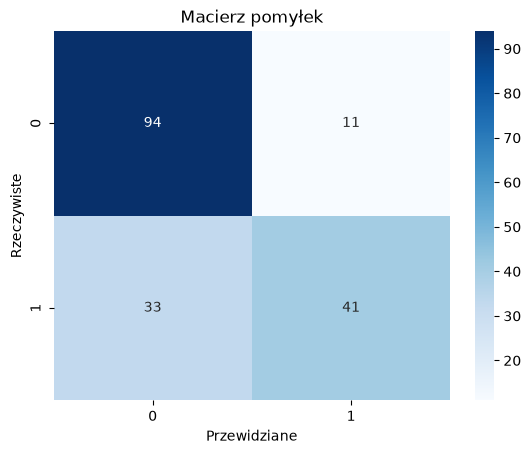

In [106]:
sns.heatmap(macierz, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Przewidziane")
plt.ylabel("Rzeczywiste")
plt.title("Macierz pomyłek")
plt.show()

## Podsumowanie Dnia 10 — pierwszy model ML

**Model regresji (przewidywanie Fare na podstawie Age, Pclass):**
- r² = 0.32, RMSE ≈ 32.4
- Umiarkowany/niski wynik — Pclass ma znacznie silniejszy wpływ niż Age,
  ale sama klasa i wiek nie wystarczają do dobrego przewidywania ceny biletu.

**Model klasyfikacji (przewidywanie Survived na podstawie Age, Pclass):**
- accuracy = 0.75, vs model naiwny = 0.59 (różnica +16 p.p.)
- Model wyraźnie lepszy niż zgadywanie większości.
- Macierz pomyłek: więcej błędów fałszywie negatywnych (33) niż fałszywie
  pozytywnych (11) — model częściej nie doceniał szans przeżycia.

**Wnioski i kierunki poprawy:**
- Nie uwzględniono płci (Sex) — cechy o silnym wpływie na przeżywalność
  (Dzień 6-8, test chi-kwadrat wykazał p≈10^-58). Dodanie tej cechy
  prawdopodobnie znacząco poprawi accuracy.
- Pclass była traktowana jako zwykła liczba, mimo że koncepcyjnie jest
  kategorią — właściwe kodowanie (np. one-hot encoding) może poprawić model.
- Dane nie były standaryzowane przed treningiem — do sprawdzenia, czy to
  wpływa na regresję logistyczną.

To pierwszy, prosty model - zostanie poprawiony w lekcji 11 przez
lepszy preprocessing (kodowanie zmiennych kategorialnych, standaryzację)
i inny algorytm klasyfikacji.

## poczatek lekcji 11 ## 

In [108]:
pd.get_dummies(dane_czyste["Sex"], drop_first=True)
#    male
# 0     1
# 1     0

,male
0,True
1,False
2,False
3,False
4,True
...,...
886,True
887,False
888,False
889,True


In [109]:
kodowanie = pd.get_dummies(dane_czyste["Sex"], drop_first=True)
print(kodowanie.head(10))
print(dane_czyste["Sex"].head(10))   # porównaj bezpośrednio z oryginałem

    male
0   True
1  False
2  False
3  False
4   True
5   True
6   True
7   True
8  False
9  False
0      male
1    female
2    female
3    female
4      male
5      male
6      male
7      male
8    female
9    female
Name: Sex, dtype: str


In [114]:
print(kodowanie.sum())
print(kodowanie["male"].dtype)

male    577
dtype: int64
bool


In [116]:
dane_czyste["male"] = kodowanie["male"]

In [120]:
kolumny_cech3 = ["Age", "Pclass", "male", "Fare"]
dane_do_modelu3 = dane_czyste[kolumny_cech3 + ["Survived"]].dropna()

X3 = dane_do_modelu3[kolumny_cech3]
y3 = dane_do_modelu3["Survived"]

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)
print(X3_train.shape)
print(X3_test.shape)

(712, 4)
(179, 4)


In [121]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X3_train_scaled = scaler.fit_transform(X3_train)
X3_test_scaled = scaler.transform(X3_test)   # UWAGA: TYLKO transform, BEZ fit!

StandardScaler wykorzystuje fit_transform() na zbiorze treningowym (oblicza
średnią/odchylenie std. TYLKO z danych treningowych), ale wyłącznie transform()
(bez fit) na zbiorze testowym — stosując TE SAME parametry, obliczone wcześniej.
Gdyby ponownie obliczyć parametry standaryzacji z danych testowych, doszłoby
do "przecieku informacji" (data leakage) ze zbioru testowego do procesu
przygotowania danych, co złamałoby zasadę uczciwej, niezależnej ewaluacji modelu.

In [130]:
model_klasyfikacja = LogisticRegression()
model_klasyfikacja.fit(X3_train_scaled, y3_train)
predykcje3 = model_klasyfikacja.predict(X3_test_scaled)
print(model_klasyfikacja.coef_)
print(kolumny_cech3)   # żeby zobaczyć, która wartość odpowiada której cesze
print(model_klasyfikacja.intercept_)

[[-0.32638325 -0.8365201  -1.21014086  0.05571342]]
['Age', 'Pclass', 'male', 'Fare']
[-0.67510696]


In [126]:
dokladnosc = accuracy_score(y3_test, predykcje3)
print(f"Dokładność (accuracy): {dokladnosc:.4f}")

Dokładność (accuracy): 0.7933


## Porównanie modeli klasyfikacji

| Model | Cechy | Preprocessing | Accuracy |
|---|---|---|---|
| LogisticRegression (Dzień 10) | Age, Pclass | brak | 0.75 |
| LogisticRegression (Dzień 11) | Age, Pclass, male, Fare | standaryzacja | 0.79 |

Dodanie płci (male) jako cechy przyniosło największą poprawę — spójne
z wcześniejszym testem chi-kwadrat (Dzień 8), który wykazał bardzo silną
statystyczną zależność między płcią a przeżywalnością (p≈10^-58).

In [127]:
# BEZ standaryzacji
model_bez_std = LogisticRegression()
model_bez_std.fit(X3_train, y3_train)
predykcje_bez_std = model_bez_std.predict(X3_test)
print(f"Accuracy BEZ standaryzacji: {accuracy_score(y3_test, predykcje_bez_std):.4f}")

# ZE standaryzacją
model_ze_std = LogisticRegression()
model_ze_std.fit(X3_train_scaled, y3_train)
predykcje_ze_std = model_ze_std.predict(X3_test_scaled)
print(f"Accuracy ZE standaryzacją: {accuracy_score(y3_test, predykcje_ze_std):.4f}")

Accuracy BEZ standaryzacji: 0.8045
Accuracy ZE standaryzacją: 0.7933


Standaryzacja danych przed LogisticRegression dała wynik 79% (vs 81% bez
standaryzacji na tych samych czterech cechach) — różnica niewielka i mogłaby
wynikać z naturalnej fluktuacji przy stosunkowo małym zbiorze testowym (~180
wierszy), a nie z jednoznacznej "szkodliwości" standaryzacji. W przeciwieństwie
do dodania cechy płci (+6 p.p.), wpływ standaryzacji na TEN konkretny model
jest znacznie mniej wyraźny.

In [128]:
from sklearn.tree import DecisionTreeClassifier

model_drzewo = DecisionTreeClassifier(max_depth=4, random_state=42)
model_drzewo.fit(X3_train_scaled, y3_train)
predykcje_drzewo = model_drzewo.predict(X3_test_scaled)

accuracy_drzewo = accuracy_score(y3_test, predykcje_drzewo)
print(f"Accuracy drzewa decyzyjnego: {accuracy_drzewo:.4f}")

Accuracy drzewa decyzyjnego: 0.7989


LogisticRegression (Age, Pclass, bez płci, Dzień 10):        75%

LogisticRegression (Age, Pclass, male, Fare, bez std.):       81%

LogisticRegression (Age, Pclass, male, Fare, ze std.):        79%

DecisionTreeClassifier (Age, Pclass, male, Fare, std.):       80%

Regresja logistyczna i drzewo decyzyjne dają bardzo zbliżone wyniki (79-81%) na tych samych czterech cechach — to sugeruje, że oba algorytmy dobrze wykorzystują dostępną informację, i żaden nie ma wyraźnej przewagi przy tym konkretnym zestawie cech. Różnice rzędu 1-2 punktów procentowych mieszczą się w naturalnej fluktuacji przy małym zbiorze testowym.

In [129]:
print(model_drzewo.feature_importances_)
print(kolumny_cech3)   # żeby zobaczyć, która wartość odpowiada której cesze

[0.07672086 0.21960828 0.58196583 0.12170503]
['Age', 'Pclass', 'male', 'Fare']


zarowno dla logistic regression, jak i dla drzewa decyzyjnego najwazniejszy i najwiekszy wplyw na przezywalnosc ma płeć (male - tak/nie, jest na minusie czyli jesli jest male to mniejsza szansa na przezycie) oraz wybrana klasa (im lepsza klasa (mniejszy numer) tym wieksza szansa na przezywalnosc

| Cechy | LogisticRegression (wartosc bezwzgledna) | drzewo |
|---|---|---|
| Age | -0.32638325 | 0.07672086 |
| Pclass | -0.8365201 | 0.21960828 |
| male | -1.21014086 | 0.58196583 |
| Fare | 0.05571342 | 0.12170503 |

Zarówno feature_importances_ (drzewo decyzyjne) jak i coef_ (regresja logistyczna,
w wartości bezwzględnej) wskazują podobną hierarchię ważności cech — spójność
między dwoma, matematycznie różnymi algorytmami wzmacnia wiarygodność wniosku
o tym, które cechy są kluczowe dla przewidywania przeżycia.

In [132]:
macierz_lr = confusion_matrix(y3_test, predykcje_ze_std)   # regresja logistyczna
macierz_drzewo = confusion_matrix(y3_test, predykcje_drzewo)   # drzewo decyzyjne

print("Regresja logistyczna:")
print(macierz_lr)
print("\nDrzewo decyzyjne:")
print(macierz_drzewo)

Regresja logistyczna:
[[89 16]
 [21 53]]

Drzewo decyzyjne:
[[92 13]
 [23 51]]


Dodanie płci jako cechy DRASTYCZNIE zmniejszyło liczbę błędów fałszywie
negatywnych (z 33 do 21-23), potwierdzając, że model wczorajszy systematycznie
niedoceniał szans przeżycia kobiet, nie mając dostępu do tej informacji.
Kosztem nieznacznego wzrostu fałszywie pozytywnych (11→13-16), łączna liczba
błędów spadła z 44 do 36-37.

In [139]:
glebokosci = [2, 4, 8, 15, 30, 60, 150]
wyniki_accuracy = []

for glebokosc in glebokosci:
    model_test = DecisionTreeClassifier(max_depth=glebokosc, random_state=42)
    model_test.fit(X3_train_scaled, y3_train)
    predykcje_test = model_test.predict(X3_test_scaled)
    dokladnosc = accuracy_score(y3_test, predykcje_test)
    wyniki_accuracy.append(dokladnosc)
    print(f"max_depth={glebokosc}: accuracy={dokladnosc:.4f}")

max_depth=2: accuracy=0.7654
max_depth=4: accuracy=0.7989
max_depth=8: accuracy=0.7821
max_depth=15: accuracy=0.7542
max_depth=30: accuracy=0.7486
max_depth=60: accuracy=0.7486
max_depth=150: accuracy=0.7486


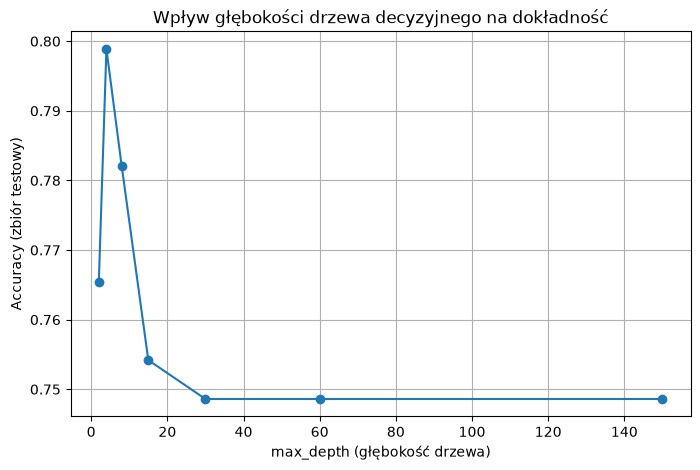

In [140]:
plt.figure(figsize=(8, 5))
plt.plot(glebokosci, wyniki_accuracy, marker="o")
plt.xlabel("max_depth (głębokość drzewa)")
plt.ylabel("Accuracy (zbiór testowy)")
plt.title("Wpływ głębokości drzewa decyzyjnego na dokładność")
plt.grid(True)
plt.show()

In [142]:
# LogisticRegression - BEZ standaryzacji (surowe X3_train, X3_test)
model_lr_bez_std = LogisticRegression()
model_lr_bez_std.fit(X3_train, y3_train)
acc_lr_bez_std = accuracy_score(y3_test, model_lr_bez_std.predict(X3_test))

# LogisticRegression - ZE standaryzacją (to już masz z zadania 4)
print(f"LogisticRegression bez standaryzacji: {acc_lr_bez_std:.4f}")
print(f"LogisticRegression ze standaryzacją: {accuracy_score(y3_test, predykcje_ze_std):.4f}")

# DecisionTree - BEZ standaryzacji
model_drzewo_bez_std = DecisionTreeClassifier(max_depth=4, random_state=42)
model_drzewo_bez_std.fit(X3_train, y3_train)
acc_drzewo_bez_std = accuracy_score(y3_test, model_drzewo_bez_std.predict(X3_test))

# DecisionTree - ZE standaryzacją (to już masz z zadania 5)
print(f"\nDecisionTree bez standaryzacji: {acc_drzewo_bez_std:.6f}")
print(f"DecisionTree ze standaryzacją: {accuracy_score(y3_test, predykcje_drzewo):.6f}")

LogisticRegression bez standaryzacji: 0.8045
LogisticRegression ze standaryzacją: 0.7933

DecisionTree bez standaryzacji: 0.798883
DecisionTree ze standaryzacją: 0.798883


Standaryzacja miała [duży/mały/żaden] wpływ na LogisticRegression (różnica
X punktów procentowych), ale [minimalny/żaden] wpływ na DecisionTreeClassifier
— zgodnie z teorią: drzewa decyzyjne opierają się na progach porównawczych,
niezależnych od skali cech, w przeciwieństwie do modeli liniowych/opartych
na odległości.

## Wpływ standaryzacji na różne typy modeli

- LogisticRegression: 0.8045 (bez std.) vs 0.7933 (ze std.) — różnica 1.12 p.p.,
  w granicach naturalnej fluktuacji przy małym zbiorze testowym (~180 wierszy).
- DecisionTree: 0.798883 (bez std.) vs 0.798883 (ze std.) — DOKŁADNIE identyczny
  wynik, jednoznacznie potwierdzający teorię: drzewa decyzyjne są całkowicie
  niewrażliwe na skalę cech, podejmując decyzje przez proste progi porównawcze,
  niezależne od jednostek/zakresu wartości

## Podsumowanie wszystkich modeli (Dni 10-11)

| Model | Cechy | Preprocessing | Accuracy |
|---|---|---|---|
| LogisticRegression | Age, Pclass | brak | 0.75 |
| LogisticRegression | Age, Pclass, male, Fare | brak | 0.8045 |
| LogisticRegression | Age, Pclass, male, Fare | standaryzacja | 0.7933 |
| DecisionTree (max_depth=4) | Age, Pclass, male, Fare | brak/standaryzacja (identyczne) | 0.7989 |

**Model naiwny (punkt odniesienia):** 0.59

## Wybór najlepszego modelu

Najlepszy wynik osiągnęła LogisticRegression na cechach Age, Pclass, male, Fare,
BEZ standaryzacji (accuracy=0.8045). Wybieram ten model jako finalny, ponieważ:

1. Osiąga najwyższą accuracy spośród przetestowanych wariantów.
2. Jest prostszy niż drzewo decyzyjne (mniej hiperparametrów do strojenia,
   jak max_depth).
3. Współczynniki (coef_) są łatwe do interpretacji — pozwalają zrozumieć
   KIERUNEK i SIŁĘ wpływu każdej cechy, co jest wartościowe przy prezentowaniu
   wyników.

Największą, jednoznaczną poprawę (75%→80%) przyniosło dodanie cechy płci —
znacznie większy efekt niż standaryzacja czy zmiana algorytmu na drzewo
decyzyjne. To potwierdza wniosek z wcześniejszych dni (testy statystyczne,
Dzień 8): płeć jest najsilniejszym pojedynczym predyktorem przeżycia wśród
dostępnych cech.

## Możliwe dalsze kierunki (poza zakresem tego kursu)
- Dodanie kolejnych cech (Embarked, SibSp, Parch)
- Wypróbowanie innych algorytmów (Random Forest, SVM)
- Strojenie hiperparametrów przez walidację krzyżową (cross-validation)

### koniec lekcji 11 ###

## Poczatek lekcji 12 ##

In [143]:
import sqlite3
polaczenie = sqlite3.connect("titanic.db")

In [144]:
dane_czyste.to_sql("pasazerowie", polaczenie, if_exists="replace", index=False)

891

In [152]:
wynik = pd.read_sql("SELECT * FROM pasazerowie LIMIT 10", polaczenie)
print(wynik)
print(wynik.columns.tolist())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male  28.0      0   
6                            McCarthy, Mr. Timothy J    male  54

In [153]:
dane_czyste.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Pełnoletni,Kategoria_wieku,male
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,True,dorosły,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,True,dorosły,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,True,dorosły,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,True,dorosły,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,True,dorosły,True
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q,True,dorosły,True
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S,True,dorosły,True
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S,False,dziecko,True
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S,True,dorosły,False
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,False,dziecko,False


In [157]:
wynik = pd.read_sql("SELECT Name, Age FROM pasazerowie WHERE Age > 60", polaczenie)
print(wynik)

                                         Name   Age
0                       Wheadon, Mr. Edward H  66.0
1              Ostby, Mr. Engelhart Cornelius  65.0
2                   Goldschmidt, Mr. George B  71.0
3                        Connors, Mr. Patrick  70.5
4                   Van der hoef, Mr. Wyckoff  61.0
5                   Stead, Mr. William Thomas  62.0
6           Andrews, Miss. Kornelia Theodosia  63.0
7                            Duane, Mr. Frank  65.0
8                   Nysveen, Mr. Johan Hansen  61.0
9                           Fortune, Mr. Mark  64.0
10                  Millet, Mr. Francis Davis  65.0
11                     Turkula, Mrs. (Hedwig)  63.0
12                    Artagaveytia, Mr. Ramon  71.0
13               Nicholson, Mr. Arthur Ernest  64.0
14                         Wright, Mr. George  62.0
15                         Harris, Mr. George  62.0
16                      Sutton, Mr. Frederick  61.0
17       Barkworth, Mr. Algernon Henry Wilson  80.0
18          

In [158]:
wynik = (dane_czyste[dane_czyste["Age"] > 60])
print(wynik)

     PassengerId  Survived  Pclass                                       Name  \
33            34         0       2                      Wheadon, Mr. Edward H   
54            55         0       1             Ostby, Mr. Engelhart Cornelius   
96            97         0       1                  Goldschmidt, Mr. George B   
116          117         0       3                       Connors, Mr. Patrick   
170          171         0       1                  Van der hoef, Mr. Wyckoff   
252          253         0       1                  Stead, Mr. William Thomas   
275          276         1       1          Andrews, Miss. Kornelia Theodosia   
280          281         0       3                           Duane, Mr. Frank   
326          327         0       3                  Nysveen, Mr. Johan Hansen   
438          439         0       1                          Fortune, Mr. Mark   
456          457         0       1                  Millet, Mr. Francis Davis   
483          484         1  

In [159]:
wynik = pd.read_sql("SELECT Pclass, AVG(Fare) FROM pasazerowie GROUP BY Pclass", polaczenie)
print(wynik)

   Pclass  AVG(Fare)
0       1  84.154687
1       2  20.662183
2       3  13.675550


In [160]:
wynik = dane_czyste.groupby("Pclass")["Fare"].mean()
print(wynik)

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


In [161]:
top_10_najdrozszych = pd.read_sql("SELECT * FROM pasazerowie ORDER BY Fare DESC LIMIT 10", polaczenie)
print(top_10_najdrozszych)



   PassengerId  Survived  Pclass                                   Name  \
0          259         1       1                       Ward, Miss. Anna   
1          680         1       1     Cardeza, Mr. Thomas Drake Martinez   
2          738         1       1                 Lesurer, Mr. Gustave J   
3           28         0       1         Fortune, Mr. Charles Alexander   
4           89         1       1             Fortune, Miss. Mabel Helen   
5          342         1       1         Fortune, Miss. Alice Elizabeth   
6          439         0       1                      Fortune, Mr. Mark   
7          312         1       1             Ryerson, Miss. Emily Borie   
8          743         1       1  Ryerson, Miss. Susan Parker "Suzette"   
9          119         0       1               Baxter, Mr. Quigg Edmond   

      Sex   Age  SibSp  Parch    Ticket      Fare Embarked  Pełnoletni  \
0  female  35.0      0      0  PC 17755  512.3292        C           1   
1    male  36.0      0    

In [162]:
print(dane_czyste.nlargest(10, "Fare"))

     PassengerId  Survived  Pclass                                   Name  \
258          259         1       1                       Ward, Miss. Anna   
679          680         1       1     Cardeza, Mr. Thomas Drake Martinez   
737          738         1       1                 Lesurer, Mr. Gustave J   
27            28         0       1         Fortune, Mr. Charles Alexander   
88            89         1       1             Fortune, Miss. Mabel Helen   
341          342         1       1         Fortune, Miss. Alice Elizabeth   
438          439         0       1                      Fortune, Mr. Mark   
311          312         1       1             Ryerson, Miss. Emily Borie   
742          743         1       1  Ryerson, Miss. Susan Parker "Suzette"   
118          119         0       1               Baxter, Mr. Quigg Edmond   

        Sex   Age  SibSp  Parch    Ticket      Fare Embarked  Pełnoletni  \
258  female  35.0      0      0  PC 17755  512.3292        C        True   


In [163]:
srednia = pd.read_sql("SELECT Pclass, AVG(Survived) from pasazerowie WHERE Fare > 50 GROUP BY Pclass", polaczenie)
print(srednia)

   Pclass  AVG(Survived)
0       1       0.733813
1       2       0.285714
2       3       0.357143


In [164]:
srednia_pandas = dane_czyste[dane_czyste["Fare"] > 50].groupby("Pclass")["Survived"].mean()
print(srednia_pandas)

Pclass
1    0.733813
2    0.285714
3    0.357143
Name: Survived, dtype: float64


| Cel	| SQL |	Pandas |
|:---:|:---:|:---:|
| Sortowanie rosnąco | ORDER BY kolumna (albo ASC)	| .sort_values("kolumna") |
| Sortowanie malejąco | ORDER BY kolumna DESC | .sort_values("kolumna", ascending=False) |
| Ograniczenie liczby wyników | LIMIT n | .head(n) |
| Połączenie obu (top N) | ORDER BY kolumna DESC LIMIT n | .nlargest(n, "kolumna") |

In [172]:
opisy_klas = pd.DataFrame({
    "Pclass": [1, 2, 3],
    "opis": ["Pierwsza klasa", "Druga klasa", "Trzecia klasa"]
    })
print(opisy_klas)

   Pclass            opis
0       1  Pierwsza klasa
1       2     Druga klasa
2       3   Trzecia klasa


In [173]:
opisy_klas.to_sql("opisy_klas", polaczenie, if_exists="replace", index=False)

3

In [174]:
#Specjalne sprawdzenie wszystkich tabel w SQL
sprawdzenie = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", polaczenie)
print(sprawdzenie)

          name
0  pasazerowie
1   opisy_klas


In [175]:
test = pd.read_sql("SELECT * FROM opisy_klas", polaczenie)
print(test)

   Pclass            opis
0       1  Pierwsza klasa
1       2     Druga klasa
2       3   Trzecia klasa


In [177]:
wynik_join = pd.read_sql("""
    SELECT pasazerowie.Name, pasazerowie.Pclass, opisy_klas.opis
    FROM pasazerowie
    JOIN opisy_klas ON pasazerowie.Pclass = opisy_klas.Pclass
    LIMIT 10
""", polaczenie)
print(wynik_join)

                                                Name  Pclass            opis
0                            Braund, Mr. Owen Harris       3   Trzecia klasa
1  Cumings, Mrs. John Bradley (Florence Briggs Th...       1  Pierwsza klasa
2                             Heikkinen, Miss. Laina       3   Trzecia klasa
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)       1  Pierwsza klasa
4                           Allen, Mr. William Henry       3   Trzecia klasa
5                                   Moran, Mr. James       3   Trzecia klasa
6                            McCarthy, Mr. Timothy J       1  Pierwsza klasa
7                     Palsson, Master. Gosta Leonard       3   Trzecia klasa
8  Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)       3   Trzecia klasa
9                Nasser, Mrs. Nicholas (Adele Achem)       2     Druga klasa


In [187]:
wynik = pd.read_sql("""
SELECT Pclass, AVG(Survived)
FROM pasazerowie 
WHERE Fare > 10 AND Sex = 'male'
GROUP BY Pclass
""", polaczenie)
print(wynik)

   Pclass  AVG(Survived)
0       1       0.387931
1       2       0.166667
2       3       0.206897


In [186]:
wynik = pd.read_sql("""
SELECT Pclass, AVG(Survived)
FROM pasazerowie
WHERE Fare > 10 AND Sex = 'female'
GROUP BY Pclass
""", polaczenie)
print(wynik)

   Pclass  AVG(Survived)
0       1       0.968085
1       2       0.921053
2       3       0.425000


In [190]:
wynik_pandas = dane_czyste[
    (dane_czyste["Fare"] > 10) & (dane_czyste["Sex"] == "male")
    ].groupby("Pclass")["Survived"].mean()
print(wynik_pandas)

Pclass
1    0.387931
2    0.166667
3    0.206897
Name: Survived, dtype: float64


In [191]:
wynik_pandas = dane_czyste[
    (dane_czyste["Fare"] > 10) & (dane_czyste["Sex"] == "female")
    ].groupby("Pclass")["Survived"].mean()
print(wynik_pandas)

Pclass
1    0.968085
2    0.921053
3    0.425000
Name: Survived, dtype: float64


|| SQL |	Pandas |
|---|---|---|
|Łączenie warunków (i)|	WHERE a AND b|	df[(warunek_a) & (warunek_b)]|
|Łączenie warunków (lub)|	WHERE a OR b|	df[(warunek_a) \| (warunek_b)]|
|Porównanie tekstu|	kolumna = 'wartosc'	|kolumna == "wartosc"|

## Porównanie: SQL vs Pandas

| Operacja | SQL | Pandas | Które wygodniejsze? |
|---|---|---|---|
| Filtrowanie (jeden warunek) | `WHERE Age > 60` | `df[df["Age"] > 60]` | Podobnie czytelne |
| Filtrowanie (wiele warunków) | `WHERE a AND b` | `df[(a) & (b)]` | SQL czytelniejszy — bez dodatkowych nawiasów |
| Agregacja | `GROUP BY Pclass, AVG(Fare)` | `df.groupby("Pclass")["Fare"].mean()` | Pandas bardziej zwięzły |
| Sortowanie + limit | `ORDER BY Fare DESC LIMIT 10` | `df.nlargest(10, "Fare")` | Pandas krótszy dla tego konkretnego przypadku |
| Łączenie tabel | `JOIN ... ON ...` | `pd.merge(..., on=...)` | Podobna czytelność |

df = DataFrame

## Wnioski

SQL wydaje się bardziej naturalny przy pisaniu WIELU warunków filtrowania
naraz (AND/OR bez dodatkowych nawiasów) oraz przy pracy z danymi, które
już są w bazie (bez potrzeby wczytywania całości do pamięci). Pandas jest
bardziej zwięzły przy agregacjach i sortowaniu z limitem (nlargest łączy
dwie operacje w jedną), oraz wygodniejszy do dalszej wizualizacji/analizy
(wynik od razu jest DataFrame, gotowy do wykresów).

W praktyce: gdy dane są w bazie SQL, warto wykonać WSTĘPNE filtrowanie/
agregację bezpośrednio w SQL (mniej danych trzeba przesłać do Pythona),
a dalszą, bardziej złożoną analizę i wizualizację robić już w Pandas.

## Projekt wersjonowany przez Git

Ten notebook jest częścią mojego portfolio analitycznego, śledzonego przez
kontrolę wersji Git od 2026.